<a href="https://colab.research.google.com/github/goitstudent123/llm-gen/blob/main/dz_topic_9_has.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Chunk 1: Install dependencies
!pip -q install -U langchain langchain-openai langgraph
!pip -q check

In [2]:
# Chunk 2: Initial imports and OpenRouter setup
import os
import re
from typing import List, Optional, TypedDict, Literal

from IPython.display import Markdown, display

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END


def read_colab_secret(name: str) -> str | None:
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None


OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

openrouter_api_key = (
    read_colab_secret("OPENROUTER_API_KEY")
    or os.getenv("OPENROUTER_API_KEY")
)

if not openrouter_api_key:
    raise ValueError(
        "Add OPENROUTER_API_KEY to Colab Secrets or set it in os.environ."
    )

OPENROUTER_MODEL = (
    read_colab_secret("OPENROUTER_MODEL")
    or os.getenv("OPENROUTER_MODEL")
    or "openai/gpt-4.1-mini"
)

OPENROUTER_HTTP_REFERER = (
    read_colab_secret("OPENROUTER_HTTP_REFERER")
    or os.getenv("OPENROUTER_HTTP_REFERER")
    or "https://colab.research.google.com"
)

OPENROUTER_APP_TITLE = (
    read_colab_secret("OPENROUTER_APP_TITLE")
    or os.getenv("OPENROUTER_APP_TITLE")
    or "Colab Support Agent"
)

llm = ChatOpenAI(
    model=OPENROUTER_MODEL,
    api_key=openrouter_api_key,
    base_url=OPENROUTER_BASE_URL,
    temperature=0.1,
    default_headers={
        "HTTP-Referer": OPENROUTER_HTTP_REFERER,
        "X-OpenRouter-Title": OPENROUTER_APP_TITLE,
    },
)

print(f"OpenRouter model: {OPENROUTER_MODEL}")

OpenRouter model: openai/gpt-4.1-mini


In [3]:
# Chunk 3: Define state types and FAQ database
class QueryClassification(TypedDict):
    type: Literal["problem", "question", "complaint"]
    category: Literal["password", "payment", "technical", "account", "general"]
    urgency: Literal["low", "medium", "high"]
    summary: str


class SupportAgentState(TypedDict):
    user_query: str
    classification: Optional[QueryClassification]
    search_results: Optional[List[str]]
    draft_response: Optional[str]
    needs_escalation: bool


FAQ_DATABASE = {
    "password": [
        "Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту",
        "Новий пароль: мінімум 8 символів з літерами та цифрами",
        "Лист не прийшов - перевірте папку спам",
    ],
    "payment": [
        "Перевірте дані картки та баланс",
        "Подвійне списання повернеться автоматично за 3-5 днів",
        "Зміна тарифу: Профіль → Підписка",
    ],
    "technical": [
        "Оновіть сторінку (F5) або очистьте кеш",
        "Спробуйте інший браузер",
        "Перевірте status.ourservice.com",
    ],
    "account": [
        "Перевірте правильність email",
        "Корпоративні акаунти: розділ 'Управління командою'",
        "Блокування - зверніться до підтримки",
    ],
    "general": [
        "Підтримка працює 24/7",
        "Час відповіді: 2-4 години",
    ],
}

In [4]:
# Chunk 4: Define helper functions
def normalize_text(text: str) -> str:
    return text.lower().replace("’", "'").replace("`", "'")


def contains_any(text: str, keywords: List[str]) -> bool:
    normalized = normalize_text(text)
    return any(keyword in normalized for keyword in keywords)


def count_words(text: str) -> int:
    return len(text.replace("\n", " ").split())


def limit_to_words(text: str, max_words: int = 50) -> str:
    words = text.replace("\n", " ").split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words]).rstrip(" .,;:") + "."


def get_category(query: str) -> str:
    text = normalize_text(query)

    if contains_any(text, ["парол", "відновити"]):
        return "password"

    if contains_any(text, ["грош", "підписк", "тариф", "плат", "списан", "картк"]):
        return "payment"

    if contains_any(text, ["сайт", "браузер", "кеш", "не працює", "помилк", "збій"]):
        return "technical"

    if contains_any(text, ["корпоратив", "користувач", "акаунт", "команд"]):
        return "account"

    return "general"


def get_query_type(query: str) -> str:
    text = normalize_text(query)

    complaint_keywords = [
        "шахрайство",
        "поверніть",
        "негайно",
        "не працює вже",
        "коли полагодите",
        "зняли гроші",
    ]

    if contains_any(text, complaint_keywords):
        return "complaint"

    if contains_any(text, ["забув", "не працює", "не можу", "помилка", "зламалось"]):
        return "problem"

    return "question"


def get_urgency(query: str, query_type: str) -> str:
    text = normalize_text(query)

    high_keywords = [
        "шахрайство",
        "негайно",
        "судов",
        "юридичн",
        "третю годину",
        "не працює вже",
        "поверніть кошти",
    ]

    if query_type == "complaint" or contains_any(text, high_keywords):
        return "high"

    if query_type == "problem":
        return "medium"

    return "low"


def build_summary(query: str, category: str, query_type: str) -> str:
    if category == "password":
        return "Користувач забув пароль і хоче відновити доступ до акаунту."

    if category == "payment" and contains_any(query, ["двічі", "списан", "зняли"]):
        return "Користувач повідомляє про подвійне списання коштів за підписку."

    if category == "payment":
        return "Користувач хоче змінити тарифний план."

    if category == "technical":
        return "Користувач повідомляє, що сайт не працює тривалий час."

    if category == "account":
        return "Користувач хоче додати нового користувача до корпоративного акаунту."

    return "Користувач звернувся із загальним питанням до підтримки."


def should_escalate(query: str, classification: QueryClassification) -> bool:
    escalation_keywords = ["шахрайство", "судов", "юридичн"]

    return (
        classification["urgency"] == "high"
        or classification["type"] == "complaint"
        or contains_any(query, escalation_keywords)
    )

In [5]:
# Chunk 5: Define graph nodes
def classify_query(state: SupportAgentState) -> dict:
    query = state["user_query"]

    category = get_category(query)
    query_type = get_query_type(query)
    urgency = get_urgency(query, query_type)

    classification: QueryClassification = {
        "type": query_type,
        "category": category,
        "urgency": urgency,
        "summary": build_summary(query, category, query_type),
    }

    return {
        "classification": classification,
    }


def search_faq(state: SupportAgentState) -> dict:
    query = state["user_query"]
    classification = state["classification"]
    category = classification["category"]

    if category == "password":
        search_results = [
            FAQ_DATABASE["password"][0],
            FAQ_DATABASE["password"][2],
        ]
    elif category == "payment" and contains_any(query, ["двічі", "списан", "зняли"]):
        search_results = [
            FAQ_DATABASE["payment"][1],
            FAQ_DATABASE["payment"][0],
        ]
    elif category == "payment":
        search_results = [
            FAQ_DATABASE["payment"][2],
        ]
    elif category == "technical":
        search_results = [
            FAQ_DATABASE["technical"][2],
            FAQ_DATABASE["technical"][0],
        ]
    elif category == "account":
        search_results = [
            FAQ_DATABASE["account"][1],
        ]
    else:
        search_results = [
            FAQ_DATABASE["general"][0],
            FAQ_DATABASE["general"][1],
        ]

    return {
        "search_results": search_results,
    }


def draft_response(state: SupportAgentState) -> dict:
    query = state["user_query"]
    classification = state["classification"]
    category = classification["category"]

    if category == "password":
        response = (
            "Натисніть 'Забули пароль?', введіть email і перевірте пошту. "
            "Якщо лист не прийшов, перевірте папку спам."
        )
    elif category == "payment" and contains_any(query, ["двічі", "списан", "зняли"]):
        response = (
            "Подвійне списання зазвичай повертається автоматично за 3-5 днів. "
            "Перевірте дані картки та баланс."
        )
    elif category == "payment":
        response = (
            "Так. Щоб змінити тариф, відкрийте Профіль → Підписка "
            "та виберіть дешевший доступний план."
        )
    elif category == "technical":
        response = (
            "Перевірте status.ourservice.com. Оновіть сторінку або очистьте кеш. "
            "Якщо збій триває, зафіксуйте час і браузер."
        )
    elif category == "account":
        response = (
            "Відкрийте корпоративний акаунт і перейдіть у розділ "
            "'Управління командою', щоб додати нового користувача."
        )
    else:
        response = "Зверніться до підтримки 24/7. Зазвичай відповідь надходить за 2-4 години."

    return {
        "draft_response": limit_to_words(response, 50),
    }


def check_escalation(state: SupportAgentState) -> dict:
    query = state["user_query"]
    classification = state["classification"]
    response = state["draft_response"]

    needs_escalation = should_escalate(query, classification)

    if needs_escalation and "передано спеціалісту" not in response.lower():
        response = f"{response}\n\n⚠️ Запит передано спеціалісту."

    return {
        "needs_escalation": needs_escalation,
        "draft_response": limit_to_words(response, 50),
    }

In [6]:
# Chunk 6: Build LangGraph support agent
def build_support_agent():
    graph = StateGraph(SupportAgentState)

    graph.add_node("classify_query", classify_query)
    graph.add_node("search_faq", search_faq)
    graph.add_node("draft_response", draft_response)
    graph.add_node("check_escalation", check_escalation)

    graph.add_edge(START, "classify_query")
    graph.add_edge("classify_query", "search_faq")
    graph.add_edge("search_faq", "draft_response")
    graph.add_edge("draft_response", "check_escalation")
    graph.add_edge("check_escalation", END)

    return graph.compile()


support_agent = build_support_agent()

print("Support agent is ready.")

Support agent is ready.


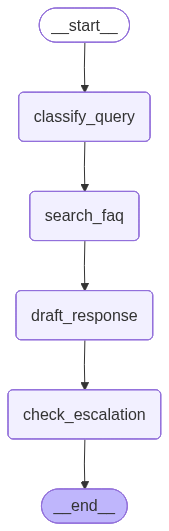

In [11]:
# Chunk 7: Display graph structure as image
from IPython.display import Image, display

try:
    graph_png = support_agent.get_graph().draw_mermaid_png()
    display(Image(graph_png))
except Exception as error:
    print("Could not render graph as PNG.")
    print(error)
    print()
    print(support_agent.get_graph().draw_mermaid())

In [12]:
# Chunk 8: Define test helpers
USE_LLM_RELEVANCY = True


def heuristic_relevancy(response: str, expected_terms: List[str]) -> float:
    normalized_response = normalize_text(response)

    if not expected_terms:
        return 1.0 if response.strip() else 0.0

    matched = sum(
        1 for term in expected_terms
        if normalize_text(term) in normalized_response
    )

    return matched / len(expected_terms)


def calculate_answer_relevancy(query: str, response: str, expected_terms: List[str]) -> float:
    heuristic_score = heuristic_relevancy(response, expected_terms)

    if not USE_LLM_RELEVANCY:
        return heuristic_score

    relevancy_prompt = f"""
Оціни релевантність відповіді до запиту числом від 0 до 1.

Запит:
{query}

Відповідь:
{response}

Поверни тільки число.
""".strip()

    try:
        result = llm.invoke(relevancy_prompt)
        text = result.content.strip()
        number_text = "".join(c for c in text if c.isdigit() or c == ".")
        llm_score = float(number_text)
        llm_score = min(max(llm_score, 0.0), 1.0)
        return max(heuristic_score, llm_score)
    except Exception:
        return heuristic_score


def bool_icon(value: bool) -> str:
    return "✅" if value else "❌"

In [13]:
# Chunk 9: Define test cases
test_cases = [
    {
        "query": "Я забув пароль від свого акаунту, як його відновити?",
        "expected_type": "problem",
        "expected_category": "password",
        "expected_urgency": "medium",
        "expected_escalation": False,
        "expected_terms": ["Забули пароль", "email", "спам"],
    },
    {
        "query": "З мене двічі зняли гроші за підписку! Це шахрайство! Поверніть кошти негайно!",
        "expected_type": "complaint",
        "expected_category": "payment",
        "expected_urgency": "high",
        "expected_escalation": True,
        "expected_terms": ["Подвійне списання", "3-5", "спеціалісту"],
    },
    {
        "query": "Чи можу я змінити тарифний план на дешевший?",
        "expected_type": "question",
        "expected_category": "payment",
        "expected_urgency": "low",
        "expected_escalation": False,
        "expected_terms": ["Профіль", "Підписка", "дешевший"],
    },
    {
        "query": "Сайт не працює вже третю годину! Коли полагодите?",
        "expected_type": "complaint",
        "expected_category": "technical",
        "expected_urgency": "high",
        "expected_escalation": True,
        "expected_terms": ["status.ourservice.com", "кеш", "спеціалісту"],
    },
    {
        "query": "Як додати нового користувача до корпоративного акаунту?",
        "expected_type": "question",
        "expected_category": "account",
        "expected_urgency": "low",
        "expected_escalation": False,
        "expected_terms": ["Управління командою", "користувача"],
    },
]

In [14]:
# Chunk 10: Run support agent tests
def test_agent():
    agent = build_support_agent()

    results = []
    relevancy_scores = []

    print("=" * 70)
    print("ТЕСТУВАННЯ АГЕНТА ТЕХНІЧНОЇ ПІДТРИМКИ")
    print("=" * 70)

    for index, case in enumerate(test_cases, 1):
        query = case["query"]

        print(f"\n{'=' * 70}")
        print(f"📧 ТЕСТ {index}/5")
        print("=" * 70)
        print(f"ЗАПИТ: {query}")
        print("-" * 70)

        initial_state = {
            "user_query": query,
            "classification": None,
            "search_results": None,
            "draft_response": None,
            "needs_escalation": False,
        }

        try:
            result = agent.invoke(
                initial_state,
                {"configurable": {"thread_id": f"test_{index}"}},
            )

            results.append(result)

            classification = result.get("classification")
            search_results = result.get("search_results") or []
            draft_response = result.get("draft_response") or ""
            needs_escalation = result.get("needs_escalation", False)

            if classification:
                print("\n📊 КЛАСИФІКАЦІЯ:")
                print(f"   Тип: {classification.get('type')}")
                print(f"   Категорія: {classification.get('category')}")
                print(f"   Терміновість: {classification.get('urgency')}")
                print(f"   Резюме: {classification.get('summary')}")

            if search_results:
                print(f"\n🔍 FAQ ({len(search_results)} пунктів):")
                for faq_index, faq in enumerate(search_results, 1):
                    print(f"   {faq_index}. {faq}")

            if draft_response:
                print("\n💬 ВІДПОВІДЬ АГЕНТА:")
                print("-" * 70)
                print(draft_response)
                print("-" * 70)

                relevancy = calculate_answer_relevancy(
                    query=query,
                    response=draft_response,
                    expected_terms=case["expected_terms"],
                )
                relevancy_scores.append(relevancy)

                print(f"\n📈 Релевантність: {relevancy:.0%}")
                print(f"🧮 Слів у відповіді: {count_words(draft_response)}")

            if needs_escalation:
                print("\n⚠️ СТАТУС: Ескаловано до спеціаліста")
            else:
                print("\n✅ СТАТУС: Оброблено автоматично")

            type_ok = classification.get("type") == case["expected_type"]
            category_ok = classification.get("category") == case["expected_category"]
            urgency_ok = classification.get("urgency") == case["expected_urgency"]
            faq_count_ok = 1 <= len(search_results) <= 2
            response_ok = bool(draft_response.strip()) and count_words(draft_response) <= 50
            escalation_ok = needs_escalation == case["expected_escalation"]

            print("\n🧪 ПЕРЕВІРКИ:")
            print(f"   {bool_icon(type_ok)} Тип")
            print(f"   {bool_icon(category_ok)} Категорія")
            print(f"   {bool_icon(urgency_ok)} Терміновість")
            print(f"   {bool_icon(faq_count_ok)} FAQ 1-2 пункти")
            print(f"   {bool_icon(response_ok)} Відповідь до 50 слів")
            print(f"   {bool_icon(escalation_ok)} Ескалація")

            result["test_checks"] = {
                "type_ok": type_ok,
                "category_ok": category_ok,
                "urgency_ok": urgency_ok,
                "faq_count_ok": faq_count_ok,
                "response_ok": response_ok,
                "escalation_ok": escalation_ok,
            }

        except Exception as error:
            print(f"❌ ПОМИЛКА: {error}")
            results.append({})

    print(f"\n{'=' * 70}")
    print("ПІДСУМКОВІ МЕТРИКИ")
    print("=" * 70)

    completed = sum(1 for result in results if result.get("draft_response"))
    tcr = completed / len(results) if results else 0
    print(f"✅ Task Completion Rate: {tcr:.0%} ({completed}/{len(results)})")

    avg_relevancy = sum(relevancy_scores) / len(relevancy_scores) if relevancy_scores else 0
    print(f"🎯 Average Answer Relevancy: {avg_relevancy:.0%}")

    escalated = sum(1 for result in results if result.get("needs_escalation"))
    escalation_rate = escalated / len(results) if results else 0
    print(f"📊 Escalation Rate: {escalated}/{len(results)} ({escalation_rate * 100:.0f}%)")

    all_checks = [
        check
        for result in results
        for check in result.get("test_checks", {}).values()
    ]

    all_checks_passed = all(all_checks) if all_checks else False
    print(f"🧪 Всі перевірки пройдено: {bool_icon(all_checks_passed)}")

    print("=" * 70)

    return results


results = test_agent()

ТЕСТУВАННЯ АГЕНТА ТЕХНІЧНОЇ ПІДТРИМКИ

📧 ТЕСТ 1/5
ЗАПИТ: Я забув пароль від свого акаунту, як його відновити?
----------------------------------------------------------------------

📊 КЛАСИФІКАЦІЯ:
   Тип: problem
   Категорія: password
   Терміновість: medium
   Резюме: Користувач забув пароль і хоче відновити доступ до акаунту.

🔍 FAQ (2 пунктів):
   1. Скидання пароля: Натисніть 'Забули пароль?' → введіть email → перевірте пошту
   2. Лист не прийшов - перевірте папку спам

💬 ВІДПОВІДЬ АГЕНТА:
----------------------------------------------------------------------
Натисніть 'Забули пароль?', введіть email і перевірте пошту. Якщо лист не прийшов, перевірте папку спам.
----------------------------------------------------------------------

📈 Релевантність: 100%
🧮 Слів у відповіді: 15

✅ СТАТУС: Оброблено автоматично

🧪 ПЕРЕВІРКИ:
   ✅ Тип
   ✅ Категорія
   ✅ Терміновість
   ✅ FAQ 1-2 пункти
   ✅ Відповідь до 50 слів
   ✅ Ескалація

📧 ТЕСТ 2/5
ЗАПИТ: З мене двічі зняли гроші за підписку